In [1]:
%matplotlib inline
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({'mathtext.default':  'regular' })
FontSize=13

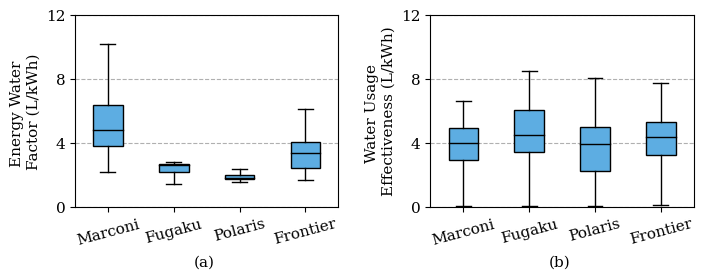

In [ ]:
def load_floats_from_file(path):
    with open(path, "r") as f:
        return [float(line.strip()) for line in f if line.strip()]

# File paths for WUE and ewf
wue_files = {
    'Marconi': "../WUE/marconi.txt",
    'Fugaku': "../WUE/fugaku.txt",
    'Polaris': "../WUE/polaris.txt",
    'Frontier': "../WUE/frontier.txt"
}

ewf_files = {
    'Marconi': "../EWF/marconi.txt",
    'Fugaku': "../EWF/fugaku.txt",
    'Polaris': "../EWF/polaris.txt",
    'Frontier': "../EWF/frontier.txt"
}

# Load data
wue = [load_floats_from_file(path) for path in wue_files.values()]
ewf = [load_floats_from_file(path) for path in ewf_files.values()]
labels = list(wue_files.keys())

# Plotting
FontSize = 13  # define or set this appropriately
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.2), gridspec_kw={
    'hspace': 0.4, 'wspace': 0.35, 'bottom': 0.2, 
    'top': 0.8, 'right': 0.995, 'left': 0.17
})

colors = ['#5DADE2'] * 4

# Plot ewf
bp1 = ax[0].boxplot(ewf, patch_artist=True, showfliers=False, 
                    medianprops=dict(color='black', linewidth=1))
ax[0].set_xticklabels(labels, rotation=15)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
ax[0].set_ylabel("Energy Water \nFactor (L/kWh)", fontsize=FontSize)
ax[0].tick_params(axis='both', labelsize=FontSize)
ax[0].set_ylim(0, 12)
ax[0].set_yticks(range(0, 13, 4))
ax[0].grid(axis='y', linestyle='--')
ax[0].text(2.3, -3.7, "(a)", fontsize=FontSize)

# Plot WUE
bp2 = ax[1].boxplot(wue, patch_artist=True, showfliers=False, 
                    medianprops=dict(color='black', linewidth=1))
ax[1].set_xticklabels(labels, rotation=15)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax[1].set_ylabel("Water Usage \nEffectiveness (L/kWh)", fontsize=FontSize)
ax[1].tick_params(axis='both', labelsize=FontSize)
ax[1].set_ylim(0, 12)
ax[1].set_yticks(range(0, 13, 4))
ax[1].grid(axis='y', linestyle='--')
ax[1].text(2.3, -3.7, "(b)", fontsize=FontSize)
plt.savefig("../figures/figure6.pdf", bbox_inches='tight')